# Analysis of Factors Affecting Used Car Prices

This project looks at some of the main factors that are related to the selling price of used cars.

## 1. Introduction

Used car prices can vary a lot depending on the age, mileage, brand and specifications of a vehicle.

In this project, I will use the CarDekho dataset to explore these factors and see which ones are most closely related to selling price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Data

I first loaded the dataset and checked its size and columns.

In [2]:
df = pd.read_csv("../data/cardekho_dataset.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 15411
Columns: 14


## 3. Getting to Know the Data

Before starting the analysis, I checked the structure of the dataset and some basic statistics.

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


In [5]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Data Cleaning

There were some duplicate rows and a few unusual values, so I removed them before starting the analysis.

In [8]:
df_clean = df.drop_duplicates().copy()

print("Rows before cleaning:", len(df))
print("Rows after removing duplicates:", len(df_clean))

Rows before cleaning: 15411
Rows after removing duplicates: 15411


In [9]:
print(df_clean[df_clean["seats"] <= 0][["car_name", "seats", "selling_price"]])

           car_name  seats  selling_price
3217     Honda City      0         115000
12619  Nissan Kicks      0        1154000


In [10]:
df_clean = df_clean[df_clean["seats"] > 0].copy()

print("Rows after removing invalid seat values:", len(df_clean))

Rows after removing invalid seat values: 15409


In [11]:
df_clean["km_driven"].describe()

count    1.540900e+04
mean     5.562045e+04
std      5.162044e+04
min      1.000000e+02
25%      3.000000e+04
50%      5.000000e+04
75%      7.000000e+04
max      3.800000e+06
Name: km_driven, dtype: float64

In [12]:
df_clean.sort_values("km_driven", ascending=False)[
    ["car_name", "vehicle_age", "km_driven", "selling_price"]
].head(10)

,car_name,vehicle_age,km_driven,selling_price
15409,Mahindra XUV500,5,3800000,1225000
11903,Mercedes-Benz E-Class,9,1325000,1350000
8772,Toyota Innova,6,950000,950000
4532,Renault Duster,4,850000,850000
6712,Volkswagen Vento,9,830000,380000
10838,Hyundai Creta,6,825000,825000
11615,Volkswagen Polo,5,820000,695000
7323,Ford Ecosport,6,720000,675000
9170,Skoda Rapid,5,675000,675000
7534,Toyota Fortuner,2,590000,2850000


## Checking Mileage

Mileage can have a strong effect on used car prices, so I checked for unusually high values before continuing with the analysis.

In [13]:
df_clean["km_driven"].describe()

count    1.540900e+04
mean     5.562045e+04
std      5.162044e+04
min      1.000000e+02
25%      3.000000e+04
50%      5.000000e+04
75%      7.000000e+04
max      3.800000e+06
Name: km_driven, dtype: float64

In [14]:
df_clean.sort_values("km_driven", ascending=False)[
    ["car_name", "vehicle_age", "km_driven", "selling_price"]
].head(10)

,car_name,vehicle_age,km_driven,selling_price
15409,Mahindra XUV500,5,3800000,1225000
11903,Mercedes-Benz E-Class,9,1325000,1350000
8772,Toyota Innova,6,950000,950000
4532,Renault Duster,4,850000,850000
6712,Volkswagen Vento,9,830000,380000
10838,Hyundai Creta,6,825000,825000
11615,Volkswagen Polo,5,820000,695000
7323,Ford Ecosport,6,720000,675000
9170,Skoda Rapid,5,675000,675000
7534,Toyota Fortuner,2,590000,2850000


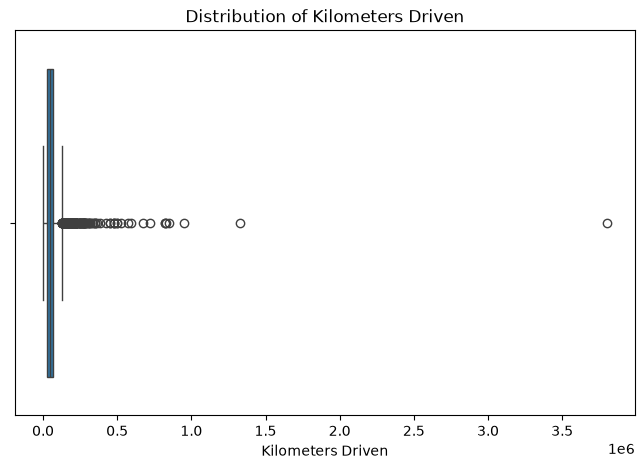

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["km_driven"])
plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.show()

### Cleaning Mileage

Most cars have mileage values within a much smaller range, but one record has an unusually high value of 3.8 million km. I removed this record as an extreme outlier while keeping the other high-mileage cars.

In [16]:
df_clean = df_clean[df_clean["km_driven"] < 3_000_000].copy()

print("Rows after mileage cleaning:", len(df_clean))

Rows after mileage cleaning: 15408


In [17]:
df_clean["km_driven"].describe()

count    1.540800e+04
mean     5.537744e+04
std      4.189013e+04
min      1.000000e+02
25%      3.000000e+04
50%      5.000000e+04
75%      7.000000e+04
max      1.325000e+06
Name: km_driven, dtype: float64

## 5. Research Question 1: Does Car Age Affect Price?

I wanted to see whether older cars generally have lower selling prices.

In [18]:
age_price = df_clean.groupby("vehicle_age")["selling_price"].mean().reset_index()

age_price

,vehicle_age,selling_price
0,0,2.230000e+06
1,1,1.096977e+06
2,2,1.143013e+06
3,3,9.770950e+05
4,4,9.509427e+05
5,5,8.187009e+05
6,6,7.285146e+05
7,7,6.990758e+05
8,8,6.259454e+05
9,9,5.924664e+05


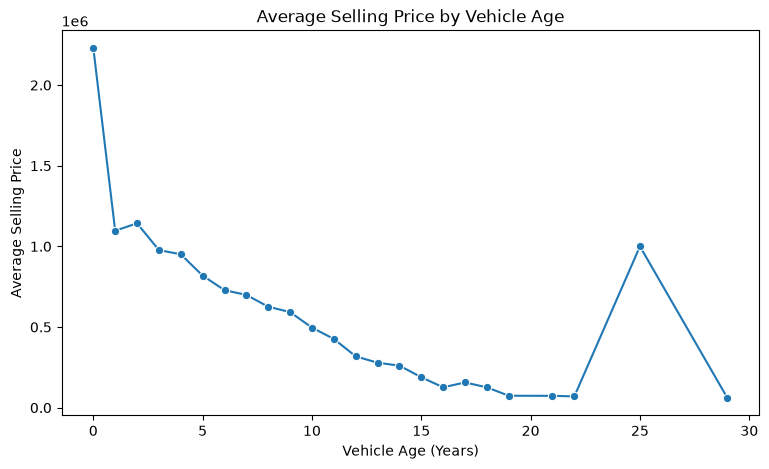

In [19]:
plt.figure(figsize=(9, 5))

sns.lineplot(data=age_price, x="vehicle_age", y="selling_price", marker="o")

plt.title("Average Selling Price by Vehicle Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Average Selling Price")
plt.show()

The average selling price generally decreases as vehicle age increases. Newer cars tend to have higher prices, while older cars are usually cheaper.

In [20]:
age_groups = pd.cut(
    df_clean["vehicle_age"],
    bins=[-1, 3, 7, 12, 20, 100],
    labels=["0-3 years", "4-7 years", "8-12 years", "13-20 years", "21+ years"]
)

age_comparison = df_clean.groupby(age_groups, observed=False)["selling_price"].agg(
    ["count", "mean", "median"]
).round(0)

age_comparison

,count,mean,median
vehicle_age,,,
0-3 years,3296,1044622.0,755000.0
4-7 years,7730,812526.0,590000.0
8-12 years,3863,541368.0,380000.0
13-20 years,513,241772.0,180000.0
21+ years,6,225000.0,77500.0


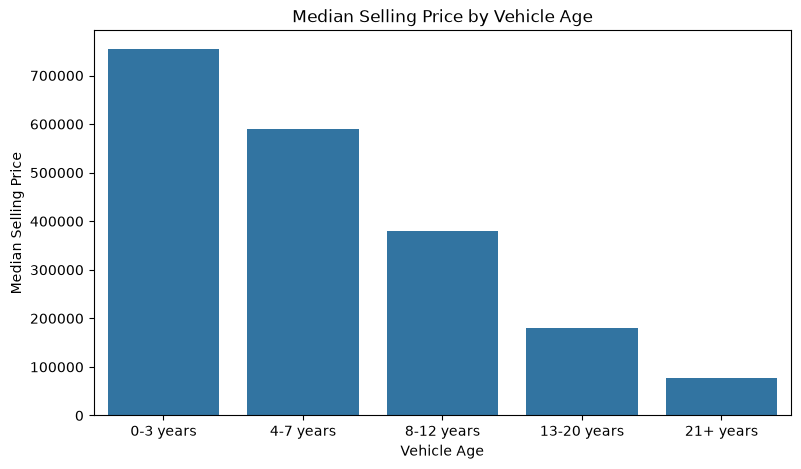

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_comparison.reset_index(),
    x="vehicle_age",
    y="median"
)

plt.title("Median Selling Price by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Median Selling Price")
plt.show()

The median selling price decreases as the vehicle gets older. Cars up to 3 years old have a median price of ₹755,000, compared with ₹180,000 for cars aged 13-20 years.

The 21+ year group has only 6 cars, so it is too small to draw a strong conclusion from.

## 6. Research Question 2: Does Mileage Affect Price?

I wanted to check whether cars that have been driven more tend to sell for less.

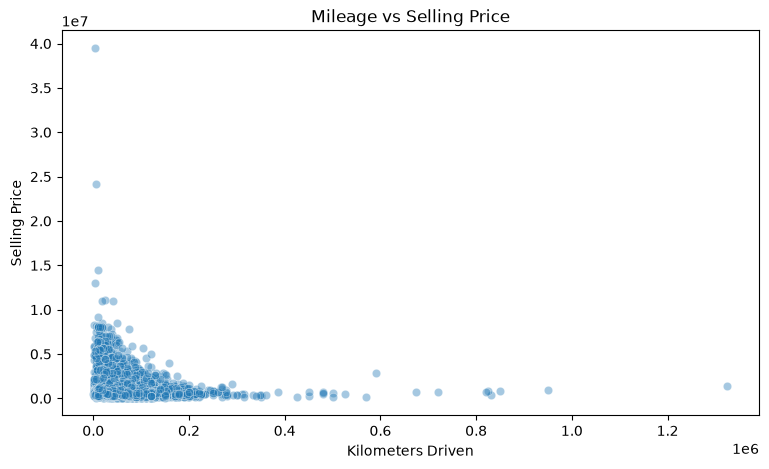

In [22]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price",
    alpha=0.4
)

plt.title("Mileage vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

In [23]:
df_clean[["km_driven", "selling_price"]].corr()

,km_driven,selling_price
km_driven,1.000000,-0.101537
selling_price,-0.101537,1.000000


The correlation between mileage and selling price is -0.101, showing a weak negative relationship. Cars with higher mileage tend to have lower prices, but the relationship is not very strong.

In [24]:
mileage_groups = pd.cut(
    df_clean["km_driven"],
    bins=[0, 30000, 60000, 100000, 200000, float("inf")],
    labels=["0-30k", "30k-60k", "60k-100k", "100k-200k", "200k+"]
)

mileage_comparison = df_clean.groupby(
    mileage_groups, observed=False
)["selling_price"].agg(["count", "mean", "median"]).round(0)

mileage_comparison

,count,mean,median
km_driven,,,
0-30k,4088,966579.0,650000.0
30k-60k,5725,754689.0,550000.0
60k-100k,4310,656271.0,500000.0
100k-200k,1200,657929.0,523000.0
200k+,85,594976.0,500000.0


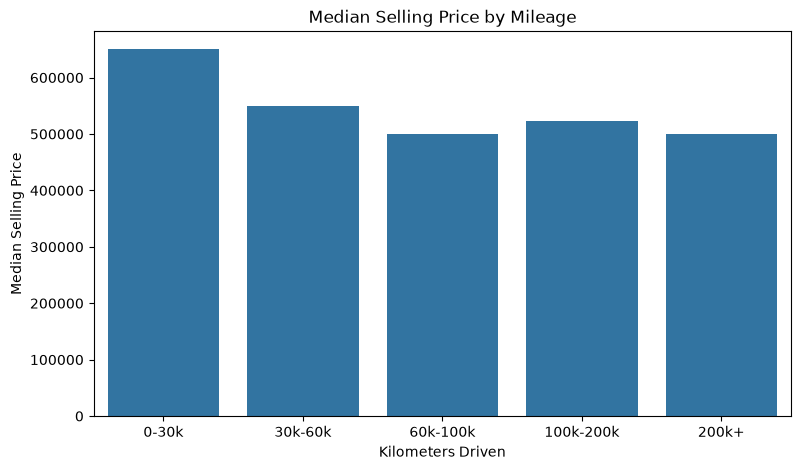

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=mileage_comparison.reset_index(),
    x="km_driven",
    y="median"
)

plt.title("Median Selling Price by Mileage")
plt.xlabel("Kilometers Driven")
plt.ylabel("Median Selling Price")
plt.show()

The median price is highest for cars with less than 30,000 km and generally falls as mileage increases. The 200k+ group is much smaller, so its result should be interpreted with some caution.

## 7. Research Question 3: Does Brand Affect Price?

Different brands target different parts of the market, so I compared their typical selling prices.

In [26]:
brand_counts = df_clean["brand"].value_counts()

brand_counts.head(15)

brand
Maruti           4992
Hyundai          2982
Honda            1484
Mahindra         1010
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Name: count, dtype: int64

In [27]:
brand_price = (
    df_clean.groupby("brand")["selling_price"]
    .agg(["count", "mean", "median"])
    .query("count >= 50")
    .sort_values("median", ascending=False)
)

brand_price

,count,mean,median
brand,,,
Land Rover,51,3.823902e+06,3400000.0
Jaguar,59,2.643034e+06,2500000.0
BMW,439,2.693827e+06,2300000.0
Mercedes-Benz,337,2.480742e+06,1800000.0
Audi,192,1.966865e+06,1700000.0
Toyota,793,1.371317e+06,1265000.0
Mahindra,1010,7.870218e+05,750000.0
Honda,1484,6.180957e+05,590000.0
Skoda,334,7.840898e+05,590000.0


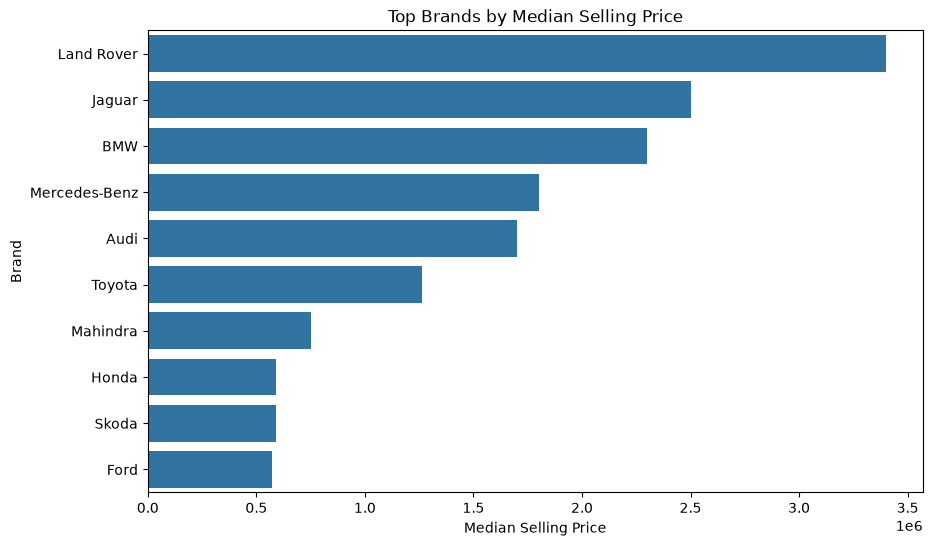

In [28]:
top_brands = brand_price.head(10).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_brands,
    x="median",
    y="brand"
)

plt.title("Top Brands by Median Selling Price")
plt.xlabel("Median Selling Price")
plt.ylabel("Brand")
plt.show()

The results show large differences in selling prices between brands. Land Rover, Jaguar, BMW, Mercedes-Benz and Audi have much higher median prices than brands such as Maruti, Hyundai and Renault.

This suggests that brand is an important factor associated with used car prices.

## 8. Research Question 4: Do Fuel and Transmission Affect Price?

I compared selling prices across different fuel and transmission types.

In [29]:
fuel_price = (
    df_clean.groupby("fuel_type")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .round(0)
)

fuel_price

,count,mean,median
fuel_type,,,
Electric,4,1853500.0,1857500.0
Diesel,7417,1000418.0,700000.0
Petrol,7642,572922.0,460000.0
CNG,301,417688.0,370000.0
LPG,44,206273.0,182500.0


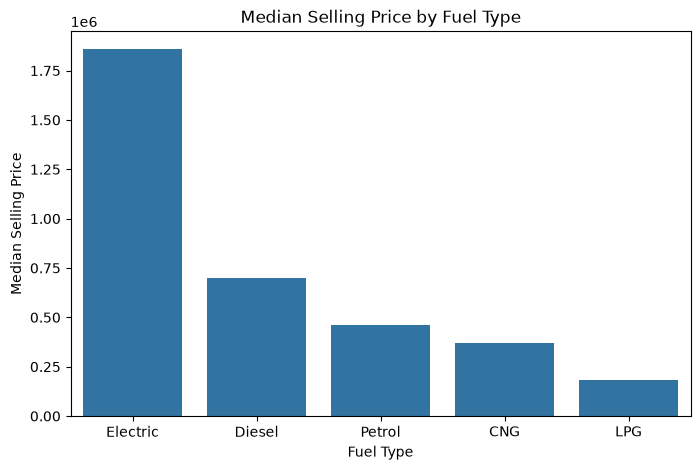

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fuel_price.reset_index(),
    x="fuel_type",
    y="median"
)

plt.title("Median Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Median Selling Price")
plt.show()

In [31]:
transmission_price = (
    df_clean.groupby("transmission_type")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .round(0)
)

transmission_price

,count,mean,median
transmission_type,,,
Automatic,3186,1579557.0,1057000.0
Manual,12222,565220.0,500000.0


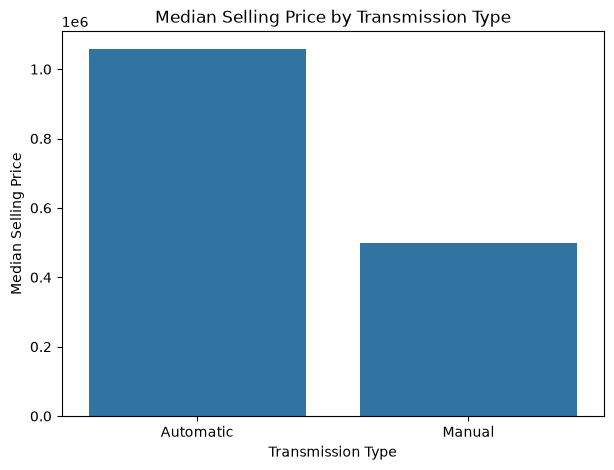

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=transmission_price.reset_index(),
    x="transmission_type",
    y="median"
)

plt.title("Median Selling Price by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Median Selling Price")
plt.show()

The results show clear differences between fuel types. Diesel cars have a higher median price than petrol, CNG and LPG cars. Electric cars have the highest median price, but there are only 4 electric cars in the dataset, so this result is not representative.

Automatic cars also have a much higher median selling price than manual cars. This suggests that transmission type is associated with selling price.

## 9. Research Question 5: Which Car Specifications Are Linked to Price?

Finally, I looked at engine size and max power to see how strongly they are related to selling price.

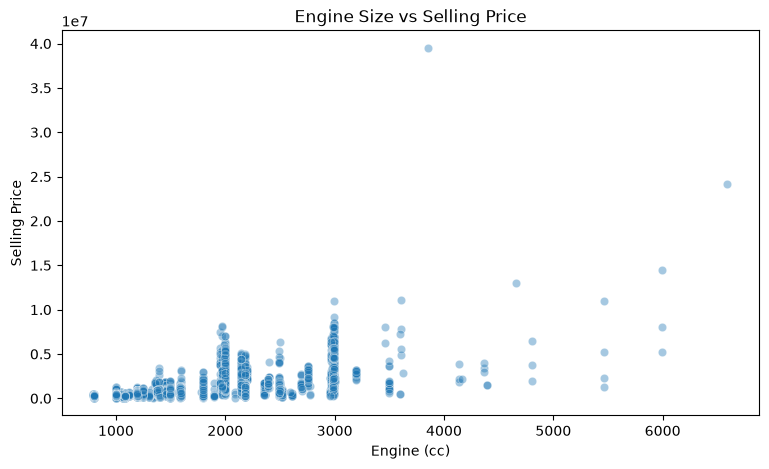

In [33]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="engine",
    y="selling_price",
    alpha=0.4
)

plt.title("Engine Size vs Selling Price")
plt.xlabel("Engine (cc)")
plt.ylabel("Selling Price")
plt.show()

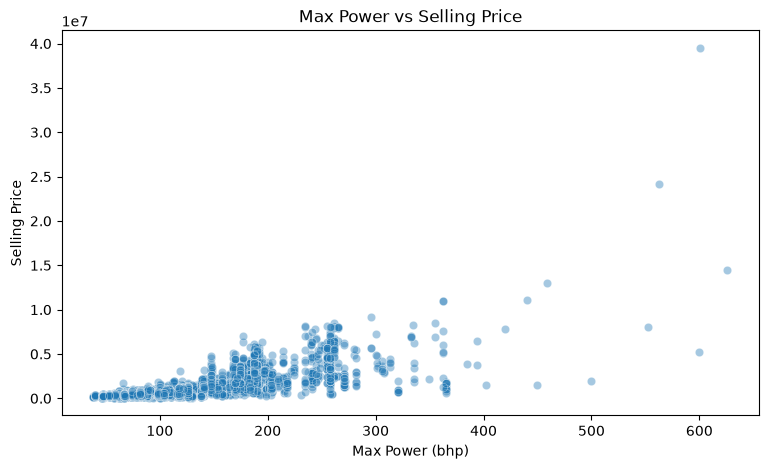

In [34]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="max_power",
    y="selling_price",
    alpha=0.4
)

plt.title("Max Power vs Selling Price")
plt.xlabel("Max Power (bhp)")
plt.ylabel("Selling Price")
plt.show()

In [35]:
df_clean[[
    "engine",
    "max_power",
    "selling_price"
]].corr()

,engine,max_power,selling_price
engine,1.000000,0.807359,0.585854
max_power,0.807359,1.000000,0.750246
selling_price,0.585854,0.750246,1.000000


The results show a positive relationship between car specifications and selling price. Max power has the strongest correlation with price at 0.751, while engine size has a moderate correlation of 0.586.

This suggests that cars with more powerful and larger engines generally have higher selling prices.

## 10. Key Findings

The main findings from the analysis are:

- Newer cars generally have higher selling prices.
- Higher mileage is associated with lower selling prices, although the relationship is weak.
- Brand shows large differences in typical selling prices.
- Diesel and automatic cars have higher median prices than most other fuel and transmission groups.
- Max power has a strong positive relationship with selling price, while engine size has a moderate positive relationship.

## 11. Conclusion

The analysis shows that used car prices are influenced by several vehicle characteristics. Age and mileage are generally associated with lower prices, while brand, transmission, engine size and max power are associated with differences in selling price.

Among the numerical specifications examined, max power has the strongest relationship with selling price. Overall, the results show that both the condition and specifications of a vehicle, as well as its brand and type, are important when comparing used car prices.

## 12. Limitations

This analysis shows relationships in the dataset, but it does not prove that one factor directly causes a change in price.

Some categories also have fewer observations than others, so their results should be interpreted with caution.